<a href="https://colab.research.google.com/github/hwasun-zip/FinStandard-EWS/blob/main/FinStandard_EWS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# 1단계: API 키 발급→상장기업 리스트 확보→재무제표 일괄 수집→원본 저장 순서로

In [7]:
# 라이브러리 설치
!pip install --upgrade opendartreader
!pip show OpenDartReader

Name: opendartreader
Version: 0.3.3
Summary: OpenDART 공시정보를 쉽게 조회할 수 있는 파이썬 라이브러리
Home-page: 
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: beautifulsoup4, click, lxml, pandas, python-dotenv, requests
Required-by: 


In [8]:
# API 키 세팅
from opendartreader import OpenDartReader
from getpass import getpass

api_key = getpass("DART API 인증키 입력: ")
dart = OpenDartReader(api_key)

DART API 인증키 입력: ··········


In [10]:
# 상장기업 리스트 확보
import pandas as pd

# 전체 공시대상 기업 목록 (상장/비상장 포함)
corp_list = dart.corp_codes.copy()

# 비상장 기업이나 특수목적법인(SPC)은 종목코드가 없어서 그 칸이 공백이므로 제외
corp_list['stock_code'] = corp_list['stock_code'].astype(str).str.strip()

# 상장사만 필터 (stock_code가 비어있지 않은 경우)
listed = corp_list[
    corp_list['stock_code'].notna() &
    (corp_list['stock_code'] != '') &
    (corp_list['stock_code'] != 'nan')
].reset_index(drop=True)

print(f"전체: {len(corp_list)}개, 상장사: {len(listed)}개")
listed.head()

전체: 118831개, 상장사: 3988개


,corp_code,corp_name,corp_eng_name,stock_code,modify_date
0,00260985,한빛네트,"HanbitNet, Inc.",036720,20170630
1,00264529,엔플렉스,"Nplex,Inc.",040130,20170630
2,00358545,동서정보기술,"Dong Seo Information Technology Co., Ltd.",055000,20170630
3,00231567,애드모바일,,032600,20170630
4,00359614,리더컴,"LEADER COMM.Co.,Ltd",056140,20170630


In [11]:
# 재무제표 소규모 샘플 수집 (50개사 테스트)
import time
import pandas as pd

def collect_finstate(corp_code, years, reprt_code='11011'):
    results = []
    for year in years:
        df = None
        for fs_div in ['CFS', 'OFS']:
            try:
                df = dart.finstate_all(corp_code, year, reprt_code, fs_div)
                if df is not None and len(df) > 0:
                    df['bsns_year'] = year
                    df['fs_div_used'] = fs_div
                    results.append(df)
                    break
            except Exception as e:
                pass
        if df is None or len(df) == 0:
            print(f"[데이터 없음] {corp_code}, {year}")
        time.sleep(0.2)
    return pd.concat(results, ignore_index=True) if results else None

# 상장사 중 50개 샘플 테스트
sample = listed.sample(50, random_state=42).reset_index(drop=True)
years = [2022, 2023, 2024]

all_data = []
for i, row in sample.iterrows():
    df = collect_finstate(row['corp_code'], years)
    if df is not None:
        df['corp_name'] = row['corp_name']
        df['stock_code'] = row['stock_code']
        all_data.append(df)
    print(f"{row['corp_name']} 완료 ({i+1}/{len(sample)})")

raw_df = pd.concat(all_data, ignore_index=True)
raw_df.to_csv('dart_raw_finstate.csv', index=False, encoding='utf-8-sig')
print(raw_df.shape)
raw_df.head(20)

# 연결재무제표는 종속회사(자회사)가 있는 기업만 작성
# 자회사가 없는 중소형 상장사는 별도재무제표(OFS)만 있고 CFS 자체가 존재하지 않는 경우가 많음

# bsns_year: 어느 사업연도 데이터인지 (2022/2023/2024 구분용)
# fs_div_used: CFS(연결)로 받았는지 OFS(별도)로 받았는지
# corp_name, stock_code: 기업명, 종목코드

# [데이터 없음]은 그 해에 아직 상장하지 않았던 경우 / 그 사이 상장폐지된 경우 / 소규모 기업이라 XBRL 전자제출 예외 대상인 경우 / 아직 해당 연도 사업보고서가 제출되지 않은 경우


reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}

reprt_code='11011', fs_div='OFS' (사업보고서, 별도(개별)제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
메쎄이상 완료 (1/50)
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}

reprt_code='11011', fs_div='OFS' (사업보고서, 별도(개별)제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}

[데이터 없음] 01117918, 2022
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}

reprt_code='11011', fs_div='OFS' (사업보고서, 별도(개별)제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}

[데이터 없음] 01117918, 2023
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}

reprt_code='11011', fs_div='OFS' (사업보고서, 별도(개별)제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}

[데이터 없음] 01117918, 2024
셀젠텍 완료 (2/50)
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표

KeyboardInterrupt: 

In [ ]:
# 계정과목이 얼마나 다양하게 표기되는지
revenue_related = raw_df[raw_df['account_nm'].str.contains('매출액|영업수익|수익', na=False)]
print(revenue_related['account_nm'].value_counts())

In [ ]:
# 키워드 매칭은 위험하고, 계정 성격을 정확히 구분해야 함 -> 진짜 '매출액' 개념에 해당하는 것만 추리기
# account_nm 대신 account_id 기준으로 매출액 관련 항목 확인
revenue_ids = raw_df[raw_df['account_nm'].isin([
    '매출액', '수익(매출액)', '영업수익', '제품매출액', '상품매출액',
    '기타매출액', '재화의 판매로 인한 수익(매출액)', '기타수익(매출액)',
    'Ⅰ. 매출액', '영업수익(매출액)', '기타영업수익'
])]

print(revenue_ids[['account_id', 'account_nm']].drop_duplicates().sort_values('account_id'))

# 영업수익 -> ifrs-full_Revenue, ifrs-full_GrossProfit이므로 account_nm만 보고 매칭하면 완전히 다른 두 개념이 섞여버림 -> account_id 기준으로 걸러야 하는 이유
# ifrs-full_OtherRevenue(기타매출액, 기타수익(매출액)) -> 매출과 무관한 기타수익이므로 핵심 매출액에 합산하면 안 됨

# 진짜 매출액: ifrs-full_Revenue / ifrs-full_RevenueFromSaleOfGoods / dart_RevenueFromSaleOfGoodsProduct / dart_RevenueFromSaleOfGoodsMerchandise

In [ ]:
# 규칙을 적용해서 표준 매출액 컬럼 만들기
REVENUE_IDS = [
    'ifrs-full_Revenue',
    'ifrs-full_RevenueFromSaleOfGoods',
    'dart_RevenueFromSaleOfGoodsProduct',
    'dart_RevenueFromSaleOfGoodsMerchandise',
]

revenue_std = raw_df[raw_df['account_id'].isin(REVENUE_IDS)].copy()
revenue_std = revenue_std[['corp_name', 'stock_code', 'bsns_year', 'fs_div_used', 'account_id', 'account_nm', 'thstrm_amount']]
revenue_std.columns = ['corp_name', 'stock_code', 'bsns_year', 'fs_div_used', 'account_id', 'original_account_nm', 'revenue_std']

print(revenue_std.shape)
revenue_std.head(10)

In [ ]:
# 매출액 외에 스코어링에 필요한 나머지 핵심 계정들(영업이익, 자산총계, 부채총계, 자본총계, 유동자산, 유동부채)가 각각 어떤 이름들로 표기되는지 탐색하는 단계

# 영업이익, 자산총계, 부채총계, 자본총계, 유동자산, 유동부채 관련 계정 탐색
keywords = ['영업이익', '자산총계', '부채총계', '자본총계', '유동자산', '유동부채']

for kw in keywords:
    print(f"\n=== '{kw}' 관련 표기 ===")
    matched = raw_df[raw_df['account_nm'].str.contains(kw, na=False)]
    print(matched[['account_id', 'account_nm']].drop_duplicates().sort_values('account_id').to_string(index=False))

# 자산총계 → ifrs-full_Assets / 자본총계 → ifrs-full_Equity

# 영업이익 → dart_OperatingIncomeLoss / ifrs-full_ProfitLossFromOperatingActivities
# 계속영업이익, 중단영업이익, 비지배지분에 귀속될 계속영업이익 → 계속/중단사업으로부터의 순이익 개념이라 완전히 다른 계정

# ifrs-full_EquityAndLiabilities → 부채및자본총계 / 자본과부채총계 / 부채와자본총계 (자산총계와 값이 같아야 하는 대차대조표 항등식(자산=부채+자본)의 합계, 부채총계x, 자본총계x)
# 부채총계 → ifrs-full_Liabilities

# 유동자산/유동부채 → ifrs-full_CurrentAssets / ifrs-full_CurrentLiabilities (비유동자산, 기타유동자산, 매각예정자산 등 관련 없음)

In [ ]:
# 2단계: 계정과목 표준화(표준코드 매핑)→핵심 재무비율 계산→이상치 탐지 및 처리(스팩 제외, fallback 매핑, clip)→업종코드(KSIC) 매핑→업종 평균 대비 상대지표 산출 순서로

In [ ]:
# 7개 핵심 계정을 골라내고, 재무비율 계산 바로 직전 단계의 표준 데이터셋을 만듦
STANDARD_ACCOUNTS = {
    'revenue':            ['ifrs-full_Revenue', 'ifrs-full_RevenueFromSaleOfGoods',
                            'dart_RevenueFromSaleOfGoodsProduct', 'dart_RevenueFromSaleOfGoodsMerchandise'],
    'operating_income':   ['dart_OperatingIncomeLoss', 'ifrs-full_ProfitLossFromOperatingActivities'],
    'total_assets':       ['ifrs-full_Assets'],
    'total_liabilities':  ['ifrs-full_Liabilities'],
    'total_equity':       ['ifrs-full_Equity'],
    'current_assets':     ['ifrs-full_CurrentAssets'],
    'current_liabilities':['ifrs-full_CurrentLiabilities'],
}

records = []
for std_name, ids in STANDARD_ACCOUNTS.items():
    sub = raw_df[raw_df['account_id'].isin(ids)].copy()
    sub = sub[['corp_name', 'stock_code', 'bsns_year', 'fs_div_used', 'thstrm_amount']]
    sub['metric'] = std_name
    records.append(sub)

long_df = pd.concat(records, ignore_index=True)

# 기업×연도별로 넓은 형태(wide)로 피벗
wide_df = long_df.pivot_table(
    index=['corp_name', 'stock_code', 'bsns_year', 'fs_div_used'],
    columns='metric',
    values='thstrm_amount',
    aggfunc='first'
).reset_index()

print(wide_df.shape)
wide_df.head(10)

In [ ]:
# 부채비율:	부채총계 / 자본총계, 자기자본 대비 부채 부담 (낮을수록 안전)
# 유동비율:	유동자산 / 유동부채,	단기 지급능력 (높을수록 안전)
# 영업이익률:	영업이익 / 매출액,	본업에서 얼마나 남기는가 (높을수록 좋음)
# 자기자본비율:	자본총계 / 자산총계,	전체 자산 중 자기자본 비중 (높을수록 안전)

ratio_df = wide_df.copy()

# 재무 수치 칼럼들을 숫자형으로 변환 (콤마 제거 후 변환)
numeric_cols = ['current_assets', 'current_liabilities', 'operating_income',
                 'revenue', 'total_assets', 'total_equity', 'total_liabilities']

for col in numeric_cols:
    ratio_df[col] = pd.to_numeric(
        ratio_df[col].astype(str).str.replace(',', ''),
        errors='coerce'  # 변환 안 되는 값은 NaN 처리
    )

# 부채비율 (%) - 낮을수록 안전
ratio_df['debt_ratio'] = ratio_df['total_liabilities'] / ratio_df['total_equity'] * 100

# 유동비율 (%) - 높을수록 안전
ratio_df['current_ratio'] = ratio_df['current_assets'] / ratio_df['current_liabilities'] * 100

# 영업이익률 (%) - 높을수록 좋음
ratio_df['operating_margin'] = ratio_df['operating_income'] / ratio_df['revenue'] * 100

# 자기자본비율 (%) - 높을수록 안전
ratio_df['equity_ratio'] = ratio_df['total_equity'] / ratio_df['total_assets'] * 100

print(ratio_df[['corp_name', 'bsns_year', 'debt_ratio', 'current_ratio', 'operating_margin', 'equity_ratio']].describe())
ratio_df[['corp_name', 'bsns_year', 'debt_ratio', 'current_ratio', 'operating_margin', 'equity_ratio']].head(10)

# operating_margin의 평균이 -inf(음의 무한대) → 매출액(revenue)이 0인 기업이 최소 하나 있어서, '영업이익(음수) ÷ 0'이 -inf로 계산된 것 (평균 전체가 오염)
# current_ratio의 최댓값이 126677% → 정상적인 기업의 유동비율은 보통 50~300% 사이인데, 126,677%는 비정상적(유동부채(분모)가 거의 0에 가까운 극단적으로 작은 기업이 있다는 뜻)

In [ ]:
# 이 이상치들이 어떤 기업인지 찾기
# 매출액 0 또는 결측인 기업 확인
print("=== 매출액 0/결측 ===")
print(ratio_df[ratio_df['revenue'].isin([0, None]) | ratio_df['revenue'].isna()][['corp_name', 'bsns_year', 'revenue', 'operating_income']])

# 유동비율 이상치 확인 (상위 5개)
print("\n=== 유동비율 상위 5개 ===")
print(ratio_df.nlargest(5, 'current_ratio')[['corp_name', 'bsns_year', 'current_assets', 'current_liabilities', 'current_ratio']])

# 스팩(SPAC, 기업인수목적회사)일 가능성이 높음 (상장은 됐지만 실제 사업이 없어서 매출도 0이고, 부채도 거의 없는 껍데기 회사)
# → SK증권제12호스팩, 하나34호스팩, 하나금융23호기업인수목적

# 정상 기업인데도 매출이 안 잡힌 경우(조이시티(게임회사), 선진(정상 상장기업), 네오이뮨텍(바이오텍)) → 매출액 매핑 규칙이 아직 완벽하지 않다는 뜻

In [ ]:
# 조이시티, 선진의 raw_df에서 매출 관련 계정 다 찾아보기 (손익계산서 대신 포괄손익계산서로 쓰고 있었음)
for company in ['조이시티', '선진']:
    print(f"\n=== {company} ===")
    sub = raw_df[(raw_df['corp_name'] == company) & (raw_df['sj_nm'] == '포괄손익계산서')]
    print(sub[['bsns_year', 'account_id', 'account_nm', 'thstrm_amount']].head(15).to_string(index=False))

# 조이시티: 영업수익(163,779,496,761) - 영업비용(156,378,822,150) ≈ 영업이익(7,400,674,611) → 영업수익이 매출액 역할을 하고 있음(ifrs-full_GrossProfit(매출총이익) 코드로 태깅함 → 매핑 문제)
# 선진:  2024년 데이터 자체가 수집이 안 됐음(수집 단계 이슈)

In [ ]:
# 매출액 fallback: Revenue 계열 코드가 없는 기업-연도에 한해
# '영업수익'이라는 이름의 GrossProfit 태깅 항목을 대체 매출액으로 사용
fallback = raw_df[
    (raw_df['account_id'] == 'ifrs-full_GrossProfit') &
    (raw_df['account_nm'] == '영업수익')
].copy()
fallback['metric'] = 'revenue'
fallback['fallback_used'] = True
print(fallback[['corp_name', 'bsns_year', 'account_nm', 'thstrm_amount']])

In [ ]:
# 선진의 2024년 데이터 실제로 뭐가 문제인지 확인
sub = raw_df[raw_df['corp_name'] == '선진']
print(sub['bsns_year'].value_counts())

In [ ]:
sub = raw_df[(raw_df['corp_name'] == '선진') & (raw_df['bsns_year'] == 2024) & (raw_df['sj_nm'] == '포괄손익계산서')]
print(sub[['account_id', 'account_nm', 'thstrm_amount']].head(10).to_string(index=False))

# thstrm_amount(당기 금액)가 전부 비어있음 → 선진의 2024년 사업보고서 자체가 DART에 뭔가 특이한 형태로 제출됐을 가능성이 큼

In [ ]:
# 1. 스팩/특수목적법인 제외
SPAC_KEYWORDS = ['스팩', '기업인수목적']
listed_clean = listed[~listed['corp_name'].str.contains('|'.join(SPAC_KEYWORDS), na=False)]

# 2. 매출액 매핑에 fallback 추가 (GrossProfit + "영업수익" 이름인 경우)
raw_df['is_revenue_fallback'] = (
    (raw_df['account_id'] == 'ifrs-full_GrossProfit') &
    (raw_df['account_nm'] == '영업수익')
)

STANDARD_ACCOUNTS = {
    'revenue':            ['ifrs-full_Revenue', 'ifrs-full_RevenueFromSaleOfGoods',
                            'dart_RevenueFromSaleOfGoodsProduct', 'dart_RevenueFromSaleOfGoodsMerchandise'],
    'operating_income':   ['dart_OperatingIncomeLoss', 'ifrs-full_ProfitLossFromOperatingActivities'],
    'total_assets':       ['ifrs-full_Assets'],
    'total_liabilities':  ['ifrs-full_Liabilities'],
    'total_equity':       ['ifrs-full_Equity'],
    'current_assets':     ['ifrs-full_CurrentAssets'],
    'current_liabilities':['ifrs-full_CurrentLiabilities'],
}

records = []
for std_name, ids in STANDARD_ACCOUNTS.items():
    sub = raw_df[raw_df['account_id'].isin(ids)].copy()
    if std_name == 'revenue':
        # revenue는 fallback 케이스도 포함
        fb = raw_df[raw_df['is_revenue_fallback']].copy()
        sub = pd.concat([sub, fb], ignore_index=True)
    sub = sub[['corp_name', 'stock_code', 'bsns_year', 'fs_div_used', 'thstrm_amount']]
    sub['metric'] = std_name
    records.append(sub)

long_df = pd.concat(records, ignore_index=True)

# 금액 숫자형 변환
long_df['thstrm_amount'] = pd.to_numeric(
    long_df['thstrm_amount'].astype(str).str.replace(',', ''), errors='coerce'
)

wide_df = long_df.pivot_table(
    index=['corp_name', 'stock_code', 'bsns_year', 'fs_div_used'],
    columns='metric',
    values='thstrm_amount',
    aggfunc='first'
).reset_index()

# 스팩 제외
wide_df = wide_df[~wide_df['corp_name'].str.contains('|'.join(SPAC_KEYWORDS), na=False)]

print(wide_df.shape)
wide_df[wide_df['corp_name'] == '조이시티']

In [ ]:
# wide_df가 109개 기업-연도로 정제됐으니 재무비율을 다시 계산

ratio_df = wide_df.copy()

numeric_cols = ['current_assets', 'current_liabilities', 'operating_income',
                 'revenue', 'total_assets', 'total_equity', 'total_liabilities']

for col in numeric_cols:
    ratio_df[col] = pd.to_numeric(ratio_df[col], errors='coerce')

ratio_df['debt_ratio'] = ratio_df['total_liabilities'] / ratio_df['total_equity'] * 100
ratio_df['current_ratio'] = ratio_df['current_assets'] / ratio_df['current_liabilities'] * 100
ratio_df['operating_margin'] = ratio_df['operating_income'] / ratio_df['revenue'] * 100
ratio_df['equity_ratio'] = ratio_df['total_equity'] / ratio_df['total_assets'] * 100

print(ratio_df[['debt_ratio', 'current_ratio', 'operating_margin', 'equity_ratio']].describe())

# operating_margin에 -inf가 남아있음 → 스팩을 제외했는데도 남았다는 건 매출액이 0이거나 결측인 정상 기업이 더 있다는 뜻 (다시 확인)
print(' ')
print(ratio_df[ratio_df['operating_margin'].isin([float('-inf'), float('inf')]) | ratio_df['revenue'].isna() | (ratio_df['revenue'] == 0)][['corp_name', 'bsns_year', 'revenue', 'operating_income']])

In [ ]:
# 네오이뮨텍: 임상 단계 바이오텍이라 실제로 매출이 0인 게 맞을 가능성이 높음 (데이터 에러가 아니라 진짜 매출 없는 정상 기업)

# 영업이익률 계산에서만 제외 (매출이 0인 행은 operating_margin만 NaN으로 남기고, 나머지 비율(부채비율, 유동비율, 자기자본비율)은 그대로 살리기 → 매출이 없는 기업도 재무 건전성(부채, 자본)은 의미 있는 정보이므로)

# 매출 0 또는 결측이면 operating_margin만 NaN 처리 (에러였던 -inf 대신)
ratio_df.loc[ratio_df['revenue'].isna() | (ratio_df['revenue'] == 0), 'operating_margin'] = None

print(ratio_df[['debt_ratio', 'current_ratio', 'operating_margin', 'equity_ratio']].describe())

# -inf는 사라졌는데 operating_margin의 최솟값이 -23,497%라는 극단치

print(' ')
print(ratio_df.nsmallest(5, 'operating_margin')[['corp_name', 'bsns_year', 'revenue', 'operating_income', 'operating_margin']])
# 네오이뮨텍이 2024년에 매출을 딱 12만 원(124,917원) 찍은 게 원인 → 사실상 0에 가까운 극소 매출이라, 여기에 영업손실(2,935만원)을 나누니까 비율이 폭발적으로 커진 거(수학적으로 정상 작동한 결과)
# → 에러가 아니라 이 비율 자체의 한계 (하한선(cap)설정해서 해결)

# 영업이익률이 특정 범위(예: -100%~100%)를 벗어나면 그 값으로 고정(clip)해서 극단치가 스코어링 전체를 왜곡하지 않게 막기
print(' ')
ratio_df['operating_margin_capped'] = ratio_df['operating_margin'].clip(-100, 100)
print(ratio_df[['debt_ratio', 'current_ratio', 'operating_margin_capped', 'equity_ratio']].describe())

In [ ]:
# 업종코드(KSIC) 수집
import time

def get_company_info(corp_code):
    try:
        info = dart.company(corp_code)
        return info
    except Exception as e:
        print(f"[에러] {corp_code}: {e}")
        return None

# wide_df에 있는 고유 기업들의 corp_code 다시 매핑 (listed에서 가져오기)
target_corps = listed[listed['corp_name'].isin(wide_df['corp_name'].unique())][['corp_code', 'corp_name']].drop_duplicates()

company_infos = []
for i, row in target_corps.iterrows():
    info = get_company_info(row['corp_code'])
    if info is not None:
        company_infos.append(info)
    time.sleep(0.2)

company_df = pd.DataFrame(company_infos)
print(company_df.shape)
company_df[['corp_name', 'induty_code']].head(10)

In [ ]:
# KSIC 코드를 실제 업종명으로 변환(통계청이 공식 KSIC 분류표를 공개하고 있는데, 이걸 매핑용 테이블로 가져와서 붙이는 작업)

import pandas as pd

# KSIC 10차 코드표 (통계청 기준) 다운로드
ksic = pd.read_csv('https://github.com/FinanceData/KSIC/raw/master/KSIC_10.csv.gz', compression='gzip')
ksic.columns = ['ksic_code', 'ksic_name']
ksic['ksic_code'] = ksic['ksic_code'].astype(str)

print(ksic.head(10))
print(ksic.shape)

# ksic_code 칼럼이 '0'"이 아니라 '1'로 나옴 → 이 상태로 매칭하면 농업 등 앞자리가 0으로 시작하는 코드들이 틀어질 수 있음

# dtype을 문자열로 강제 지정해서 다시 읽어야 함
import pandas as pd

ksic = pd.read_csv('https://github.com/FinanceData/KSIC/raw/master/KSIC_10.csv.gz', compression='gzip', dtype=str)
ksic.columns = ['ksic_code', 'ksic_name']

print(' ')
print(ksic.head(5))

In [ ]:
company_df['induty_code'] = company_df['induty_code'].astype(str).str.strip()
company_df['ksic_mid_code'] = company_df['induty_code'].str[:2]

ksic_mid = ksic[ksic['ksic_code'].str.len() == 2].rename(columns={'ksic_code': 'ksic_mid_code', 'ksic_name': 'industry_mid_name'})

company_df = company_df.merge(ksic_mid, on='ksic_mid_code', how='left')

print(company_df[['corp_name', 'induty_code', 'ksic_mid_code', 'industry_mid_name']].head(15))

In [ ]:
# 이 업종 정보를 wide_df(재무비율 데이터)에 합쳐야 함 (corp_name 기준으로 조인)

# wide_df에 업종 정보 결합
merged_df = ratio_df.merge(
    company_df[['corp_name', 'induty_code', 'ksic_mid_code', 'industry_mid_name']],
    on='corp_name', how='left'
)

print(merged_df.shape)
print(merged_df['industry_mid_name'].isna().sum(), "개 기업이 업종 매칭 안 됨")
merged_df[['corp_name', 'industry_mid_name', 'debt_ratio', 'current_ratio', 'operating_margin_capped', 'equity_ratio']].head(10)

# company_df의 기업명에는 '(주)큐에스아이', '송원산업(주)'처럼 법인 형태 표기(주식회사/㈜)가 붙어있는데, ratio_df 쪽은 'BYC', 'CJ CGV'처럼 그냥 상호명만 있어서 매칭 실패 → stock_code(종목코드)로 합치기

In [ ]:
# stock_code 기준으로 병합
company_df['stock_code'] = company_df['stock_code'].astype(str).str.strip()
ratio_df['stock_code'] = ratio_df['stock_code'].astype(str).str.strip()

merged_df = ratio_df.merge(
    company_df[['stock_code', 'induty_code', 'ksic_mid_code', 'industry_mid_name']],
    on='stock_code', how='left'
)

print(merged_df.shape)
print(merged_df['industry_mid_name'].isna().sum(), "개 기업이 업종 매칭 안 됨")
merged_df[['corp_name', 'industry_mid_name', 'debt_ratio', 'current_ratio', 'operating_margin_capped', 'equity_ratio']].head(10)

In [ ]:
# 업종별 평균 대비 상대지표
# 이 업종에 속한 기업들의 평균 부채비율이 얼마인지 계산하고, 각 기업의 부채비율이 그 평균 대비 몇 배인지 구하기

# 업종별 평균 부채비율 계산
industry_avg = merged_df.groupby('industry_mid_name')['debt_ratio'].transform('mean')

# 업종 대비 상대 부채비율 (1.0 = 업종 평균과 동일, 1.5 = 업종 평균보다 50% 높음)
merged_df['debt_ratio_vs_industry'] = merged_df['debt_ratio'] / industry_avg

print(merged_df[['corp_name', 'industry_mid_name', 'debt_ratio', 'debt_ratio_vs_industry']].sort_values('debt_ratio_vs_industry', ascending=False).head(10))

# 서진오토모티브가 상위 3개 중 3개를 다 차지(3개년 다) → 지속적으로 업종 평균 대비 부채비율이 3배 가까이 높은 구조적 특성을 가진 기업
# 유니온머티리얼(비금속 광물제품)은 절대 부채비율 자체는 796%로 서진오토모티브(476%)보다 훨씬 높음 but, vs_industry는 오히려 서진오토모티브보다 낮게(2.1배) 나옴 → 업종 상대지표가 제대로 작동하고 있음

# → "절대 부채비율 순위"와 "업종 대비 순위"가 다르게 나온다는 걸 데이터로 증명

In [ ]:
# 이 로직을 나머지 3개 지표(유동비율, 영업이익률, 자기자본비율)에도 똑같이 적용

ratio_cols = ['debt_ratio', 'current_ratio', 'operating_margin_capped', 'equity_ratio']

for col in ratio_cols:
    industry_avg = merged_df.groupby('industry_mid_name')[col].transform('mean')
    merged_df[f'{col}_vs_industry'] = merged_df[col] / industry_avg

vs_industry_cols = [f'{c}_vs_industry' for c in ratio_cols]
print(merged_df[['corp_name', 'industry_mid_name'] + vs_industry_cols].head(10))

# operating_margin_capped_vs_industry가 극단적으로 튀는 값들이 있음 (CJ CGV -16.9배, 10.96배 등) → 분모(업종 평균 영업이익률)가 0에 가까울 때
# 해결 방안: 영업이익률만 나눗셈 대신 '차이'로 계산

In [ ]:
# '업종 평균보다 몇 배'가 아니라 '업종 평균보다 몇%p 높거나 낮은가'로. → 분모가 0이어도 문제가 안 생김

ratio_cols = ['debt_ratio', 'current_ratio', 'equity_ratio']  # 비율(division) 방식 유지
diff_cols = ['operating_margin_capped']  # 차이(subtraction) 방식으로 변경

merged_df_clean = merged_df.copy()

for col in ratio_cols:
    industry_avg = merged_df_clean.groupby('industry_mid_name')[col].transform('mean')
    merged_df_clean[f'{col}_vs_industry'] = merged_df_clean[col] / industry_avg

for col in diff_cols:
    industry_avg = merged_df_clean.groupby('industry_mid_name')[col].transform('mean')
    merged_df_clean[f'{col}_vs_industry'] = merged_df_clean[col] - industry_avg  # 나눗셈 대신 차이

vs_cols = [f'{c}_vs_industry' for c in ratio_cols + diff_cols]
print(merged_df_clean[['corp_name', 'industry_mid_name'] + vs_cols].describe())

# 영업이익률은 "업종 평균보다 몇 %p 높은/낮은 수익성인가"로 해석되고, 나머지 3개는 기존처럼 "업종 평균의 몇 배인가"로 유지

In [ ]:
# 3단계: 4개 상대지표 정규화(MinMaxScaler) → 방향 통일(위험할수록 높은 점수) → 가중합으로 0~100점 부실위험 스코어 산출

In [ ]:
# 스코어링 (4개 상대지표를 정규화하고 가중합해서 0~100점 부실위험 스코어를 만드는 단계)

from sklearn.preprocessing import MinMaxScaler

score_df = merged_df_clean.copy()

# 방향성 정리: 위험할수록 점수가 높아지도록 부호 통일
# - debt_ratio_vs_industry: 높을수록 위험 (그대로 사용)
# - current_ratio_vs_industry: 높을수록 안전 → 부호 반전
# - equity_ratio_vs_industry: 높을수록 안전 → 부호 반전
# - operating_margin_capped_vs_industry: 높을수록 안전(수익성 좋음) → 부호 반전

score_df['risk_debt'] = score_df['debt_ratio_vs_industry']
score_df['risk_current'] = -score_df['current_ratio_vs_industry']
score_df['risk_equity'] = -score_df['equity_ratio_vs_industry']
score_df['risk_margin'] = -score_df['operating_margin_capped_vs_industry']

risk_cols = ['risk_debt', 'risk_current', 'risk_equity', 'risk_margin']

# 0~1로 정규화 (결측은 일단 제외하고 계산)
scaler = MinMaxScaler()
score_df_valid = score_df.dropna(subset=risk_cols).copy()
score_df_valid[risk_cols] = scaler.fit_transform(score_df_valid[risk_cols])

# 동일 가중치로 가중합 (0~100점)
score_df_valid['risk_score'] = score_df_valid[risk_cols].mean(axis=1) * 100

print(score_df_valid[['corp_name', 'bsns_year', 'risk_score']].sort_values('risk_score', ascending=False).head(15))

# 서진오토모티브가 3개년 다 상위 4위 안에 들면서 최종 스코어에서도 1위로 나옴 → 스코어링 로직이 "지속적으로 위험한 재무구조"를 제대로 짚어내고 있다는 신호
# 디케이티, 빛과전자처럼 3개년 다 상위권에 반복해서 등장하는 기업들이 있는 반면, 인베니아는 2023~2024년 2개년만 나오고, KS인더스트리는 2022년 한 번만 나옴 → 이 스코어가 "구조적으로 위험한 기업"과 "특정 연도에만 일시적으로 안 좋았던 기업"을 구분해내고 있는지가 검증 단계에서 중요한 포인트

In [13]:
# 중간에 세션이 끊겨도 데이터 손실이 없도록 체크포인트 저장

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 스팩 제외 후 전체 대상 확정
SPAC_KEYWORDS = ['스팩', '기업인수목적']
listed_full = listed[~listed['corp_name'].str.contains('|'.join(SPAC_KEYWORDS), na=False)].reset_index(drop=True)
print(f"수집 대상: {len(listed_full)}개사")

In [ ]:
import pandas as pd
check_df = pd.read_csv('/content/drive/MyDrive/dart_full_2024.csv')
print(f"저장된 기업 수: {check_df['stock_code'].nunique()}개 / 3740개")

In [ ]:
import time
import os

SAVE_PATH = '/content/drive/MyDrive/dart_full_2024.csv'
ATTEMPTED_PATH = '/content/drive/MyDrive/dart_attempted_log.csv'
CHECKPOINT_EVERY = 50

def collect_finstate_single_year(corp_code, year=2024, reprt_code='11011'):
    for fs_div in ['CFS', 'OFS']:
        try:
            df = dart.finstate_all(corp_code, year, reprt_code, fs_div)
            if df is not None and len(df) > 0:
                df['bsns_year'] = year
                df['fs_div_used'] = fs_div
                return df
        except Exception:
            pass
    return None

# 성공 데이터 로드 + 중복 제거
done_df = pd.read_csv(SAVE_PATH, low_memory=False, dtype={'stock_code': str})
done_df['stock_code'] = done_df['stock_code'].str.zfill(6)
done_df = done_df.drop_duplicates()  # 중복 행 제거
done_df.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')  # 정리된 걸로 재저장
done_corps = set(done_df['stock_code'])

# 시도 이력 로드
if os.path.exists(ATTEMPTED_PATH):
    attempted_df = pd.read_csv(ATTEMPTED_PATH, dtype={'stock_code': str})
    attempted_df['stock_code'] = attempted_df['stock_code'].str.zfill(6)
    attempted_corps = set(attempted_df['stock_code'])
else:
    attempted_df = pd.DataFrame()
    attempted_corps = set()

# 핵심 수정: 두 이력을 합쳐서 스킵 대상 확정
skip_corps = done_corps | attempted_corps

listed_full['stock_code'] = listed_full['stock_code'].astype(str).str.zfill(6)
print(f"성공: {len(done_corps)}개, 시도이력: {len(attempted_corps)}개, 총 스킵 대상: {len(skip_corps)}개")

buffer = []
attempted_buffer = []

for i, row in listed_full.iterrows():
    if row['stock_code'] in skip_corps:
        continue

    df = collect_finstate_single_year(row['corp_code'])
    if df is not None:
        df['corp_name'] = row['corp_name']
        df['stock_code'] = row['stock_code']
        buffer.append(df)

    attempted_buffer.append({'stock_code': row['stock_code']})
    skip_corps.add(row['stock_code'])
    time.sleep(0.15)

    if (i + 1) % CHECKPOINT_EVERY == 0:
        if buffer:
            new_data = pd.concat(buffer, ignore_index=True)
            done_df = pd.concat([done_df, new_data], ignore_index=True)
            done_df.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')
            buffer = []
        if attempted_buffer:
            att_new = pd.DataFrame(attempted_buffer)
            attempted_df = pd.concat([attempted_df, att_new], ignore_index=True) if len(attempted_df) > 0 else att_new
            attempted_df.to_csv(ATTEMPTED_PATH, index=False, encoding='utf-8-sig')
            attempted_buffer = []
        print(f"진행률: {i+1}/{len(listed_full)} ({(i+1)/len(listed_full)*100:.1f}%) - 저장됨 (누적 성공: {done_df['stock_code'].nunique()}개)")

if buffer:
    new_data = pd.concat(buffer, ignore_index=True)
    done_df = pd.concat([done_df, new_data], ignore_index=True)
    done_df.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')
if attempted_buffer:
    att_new = pd.DataFrame(attempted_buffer)
    attempted_df = pd.concat([attempted_df, att_new], ignore_index=True) if len(attempted_df) > 0 else att_new
    attempted_df.to_csv(ATTEMPTED_PATH, index=False, encoding='utf-8-sig')

print("전체 수집 완료!")

In [ ]:
final_df = pd.read_csv('/content/drive/MyDrive/dart_full_2024.csv', low_memory=False, dtype={'stock_code': str})
final_df = final_df.drop_duplicates()  # 혹시 남아있을 중복 최종 제거
final_df.to_csv('/content/drive/MyDrive/dart_full_2024.csv', index=False, encoding='utf-8-sig')

print(f"최종 수집 기업 수: {final_df['stock_code'].nunique()}개 / 3740개 (대상)")
print(f"전체 행 수: {len(final_df)}")

In [ ]:
# 실패한 기업 목록 (전체 대상 - 성공한 것)
failed_stock_codes = set(listed_full['stock_code']) - set(final_df['stock_code'])
failed_corps = listed_full[listed_full['stock_code'].isin(failed_stock_codes)].copy()

print(f"실패한 기업 수: {len(failed_corps)}개")
print(failed_corps[['corp_name', 'stock_code', 'modify_date']].head(20))

# 2017년 6월 30일 이후로 DART 시스템에서 이 기업 정보가 단 한 번도 갱신된 적이 없다는 뜻 = 현재 시점에 실질적으로 존재하지 않거나 활동을 멈춘 기업

In [ ]:
# 업종정보 수집 (2663개, 체크포인트 저장)
import time
import os

COMPANY_SAVE_PATH = '/content/drive/MyDrive/dart_company_info.csv'
COMPANY_ATTEMPTED_PATH = '/content/drive/MyDrive/dart_company_attempted.csv'
CHECKPOINT_EVERY = 50

# 대상: 재무제표 수집에 성공한 2,663개 기업만
target_stock_codes = final_df['stock_code'].astype(str).str.zfill(6).unique()
target_corps = listed_full[listed_full['stock_code'].isin(target_stock_codes)][['corp_code', 'corp_name', 'stock_code']].drop_duplicates().reset_index(drop=True)
print(f"업종정보 수집 대상: {len(target_corps)}개사")

def get_company_info_safe(corp_code):
    try:
        info = dart.company(corp_code)
        return info
    except Exception:
        return None

# 기존 진행분 로드
if os.path.exists(COMPANY_SAVE_PATH):
    company_done_df = pd.read_csv(COMPANY_SAVE_PATH, low_memory=False, dtype={'stock_code': str})
    company_done_df['stock_code'] = company_done_df['stock_code'].str.zfill(6)
else:
    company_done_df = pd.DataFrame()

if os.path.exists(COMPANY_ATTEMPTED_PATH):
    company_attempted_df = pd.read_csv(COMPANY_ATTEMPTED_PATH, dtype={'stock_code': str})
    company_attempted_df['stock_code'] = company_attempted_df['stock_code'].str.zfill(6)
    company_attempted = set(company_attempted_df['stock_code'])
else:
    company_attempted_df = pd.DataFrame()
    company_attempted = set()

done_stock_codes = set(company_done_df['stock_code']) if len(company_done_df) > 0 else set()
skip_set = done_stock_codes | company_attempted

print(f"이미 완료: {len(done_stock_codes)}개, 스킵 대상: {len(skip_set)}개")

buffer = []
attempted_buffer = []

for i, row in target_corps.iterrows():
    stock_code = str(row['stock_code']).zfill(6)
    if stock_code in skip_set:
        continue

    info = get_company_info_safe(row['corp_code'])
    if info is not None:
        info['stock_code'] = stock_code
        buffer.append(info)

    attempted_buffer.append({'stock_code': stock_code})
    skip_set.add(stock_code)
    time.sleep(0.15)

    if (i + 1) % CHECKPOINT_EVERY == 0:
        if buffer:
            new_data = pd.DataFrame(buffer)
            company_done_df = pd.concat([company_done_df, new_data], ignore_index=True) if len(company_done_df) > 0 else new_data
            company_done_df.to_csv(COMPANY_SAVE_PATH, index=False, encoding='utf-8-sig')
            buffer = []
        if attempted_buffer:
            att_new = pd.DataFrame(attempted_buffer)
            company_attempted_df = pd.concat([company_attempted_df, att_new], ignore_index=True) if len(company_attempted_df) > 0 else att_new
            company_attempted_df.to_csv(COMPANY_ATTEMPTED_PATH, index=False, encoding='utf-8-sig')
            attempted_buffer = []
        print(f"진행률: {i+1}/{len(target_corps)} ({(i+1)/len(target_corps)*100:.1f}%) - 저장됨 (누적: {company_done_df['stock_code'].nunique()}개)")

if buffer:
    new_data = pd.DataFrame(buffer)
    company_done_df = pd.concat([company_done_df, new_data], ignore_index=True) if len(company_done_df) > 0 else new_data
    company_done_df.to_csv(COMPANY_SAVE_PATH, index=False, encoding='utf-8-sig')
if attempted_buffer:
    att_new = pd.DataFrame(attempted_buffer)
    company_attempted_df = pd.concat([company_attempted_df, att_new], ignore_index=True) if len(company_attempted_df) > 0 else att_new
    company_attempted_df.to_csv(COMPANY_ATTEMPTED_PATH, index=False, encoding='utf-8-sig')

print("업종정보 수집 완료!")

In [15]:
import pandas as pd

final_df = pd.read_csv('/content/drive/MyDrive/dart_full_2024.csv', low_memory=False, dtype={'stock_code': str})
company_df = pd.read_csv('/content/drive/MyDrive/dart_company_info.csv', low_memory=False, dtype={'stock_code': str})

print("재무제표:", final_df.shape)
print("업종정보:", company_df.shape)

재무제표: (476729, 24)
업종정보: (2663, 19)


In [ ]:
# 4단계: 상장폐지/관리종목 지정 이력(부실 라벨) 수집 → 스코어 등급별 실제 부실률 상관관계 검증

In [16]:
# 50개 샘플로 검증했던 로직을 전체 데이터에 적용 (계정과목 표준화 → 재무비율 계산 → 이상치 처리 → 업종 매핑 → 업종 상대화)
import pandas as pd
import numpy as np

# ---- 1. 계정과목 표준화 매핑 ----
STANDARD_ACCOUNTS = {
    'revenue':            ['ifrs-full_Revenue', 'ifrs-full_RevenueFromSaleOfGoods',
                            'dart_RevenueFromSaleOfGoodsProduct', 'dart_RevenueFromSaleOfGoodsMerchandise'],
    'operating_income':   ['dart_OperatingIncomeLoss', 'ifrs-full_ProfitLossFromOperatingActivities'],
    'total_assets':       ['ifrs-full_Assets'],
    'total_liabilities':  ['ifrs-full_Liabilities'],
    'total_equity':       ['ifrs-full_Equity'],
    'current_assets':     ['ifrs-full_CurrentAssets'],
    'current_liabilities':['ifrs-full_CurrentLiabilities'],
}

# revenue fallback (GrossProfit 태깅인데 실질적으로 매출액인 경우 - 조이시티 사례)
final_df['is_revenue_fallback'] = (
    (final_df['account_id'] == 'ifrs-full_GrossProfit') &
    (final_df['account_nm'] == '영업수익')
)

records = []
for std_name, ids in STANDARD_ACCOUNTS.items():
    sub = final_df[final_df['account_id'].isin(ids)].copy()
    if std_name == 'revenue':
        fb = final_df[final_df['is_revenue_fallback']].copy()
        sub = pd.concat([sub, fb], ignore_index=True)
    sub = sub[['corp_name', 'stock_code', 'bsns_year', 'fs_div_used', 'thstrm_amount']]
    sub['metric'] = std_name
    records.append(sub)

long_df = pd.concat(records, ignore_index=True)
long_df['thstrm_amount'] = pd.to_numeric(
    long_df['thstrm_amount'].astype(str).str.replace(',', ''), errors='coerce'
)

wide_df_full = long_df.pivot_table(
    index=['corp_name', 'stock_code', 'bsns_year', 'fs_div_used'],
    columns='metric', values='thstrm_amount', aggfunc='first'
).reset_index()

# ---- 2. 스팩 제외 ----
SPAC_KEYWORDS = ['스팩', '기업인수목적']
wide_df_full = wide_df_full[~wide_df_full['corp_name'].str.contains('|'.join(SPAC_KEYWORDS), na=False)]

print(f"1단계 결과: {wide_df_full.shape}")
wide_df_full.head()

1단계 결과: (2661, 11)


metric,corp_name,stock_code,bsns_year,fs_div_used,current_assets,current_liabilities,operating_income,revenue,total_assets,total_equity,total_liabilities
0,3S,060310,2024,CFS,2.304189e+10,1.250090e+10,1.164030e+09,4.359535e+10,6.379094e+10,4.844017e+10,1.535077e+10
1,AJ네트웍스,095570,2024,CFS,3.044345e+11,6.310189e+11,7.279021e+10,1.014156e+12,1.717770e+12,4.437232e+11,1.274047e+12
2,AK홀딩스,006840,2024,CFS,1.346081e+12,2.673499e+12,1.303201e+11,4.488281e+12,5.336875e+12,1.245029e+12,4.091846e+12
3,APS,054620,2024,CFS,9.909632e+10,1.529014e+11,-2.263756e+10,9.396501e+10,4.132091e+11,2.257144e+11,1.874947e+11
4,APS이노베이션,079810,2024,CFS,1.623876e+11,6.878123e+10,5.356272e+09,1.463742e+11,2.375357e+11,1.649803e+11,7.255535e+10


In [17]:
# 재무비율 계산 + 이상치 처리 (전체 데이터 적용)
ratio_df_full = wide_df_full.copy()

# 숫자형 변환
numeric_cols = ['current_assets', 'current_liabilities', 'operating_income',
                 'revenue', 'total_assets', 'total_equity', 'total_liabilities']
for col in numeric_cols:
    ratio_df_full[col] = pd.to_numeric(ratio_df_full[col], errors='coerce')

# 4개 비율 계산
ratio_df_full['debt_ratio'] = ratio_df_full['total_liabilities'] / ratio_df_full['total_equity'] * 100
ratio_df_full['current_ratio'] = ratio_df_full['current_assets'] / ratio_df_full['current_liabilities'] * 100
ratio_df_full['operating_margin'] = ratio_df_full['operating_income'] / ratio_df_full['revenue'] * 100
ratio_df_full['equity_ratio'] = ratio_df_full['total_equity'] / ratio_df_full['total_assets'] * 100

# 매출 0/결측이면 영업이익률만 NaN 처리 (inf 방지)
ratio_df_full.loc[ratio_df_full['revenue'].isna() | (ratio_df_full['revenue'] == 0), 'operating_margin'] = None

# 극단치 clip (초소액 매출로 인한 폭주 방지)
ratio_df_full['operating_margin_capped'] = ratio_df_full['operating_margin'].clip(-100, 100)

print(ratio_df_full[['debt_ratio', 'current_ratio', 'operating_margin_capped', 'equity_ratio']].describe())

# current_ratio가 inf(무한대) → 유동부채가 0인 기업이 있다
# debt_ratio 최솟값이 -4912%, equity_ratio 최솟값이 -838% → 자본총계가 마이너스(완전자본잠식) 기업이
# 완전자본잠식은 부실위험 스코어링에서 가장 중요하게 잡아내야 하는 상태(제외하지 말고, 스코어에 정확히 반영되도록 다듬는 게 맞음)

metric    debt_ratio  current_ratio  operating_margin_capped  equity_ratio
count    2661.000000    2580.000000              2575.000000   2660.000000
mean      134.833969            inf                -4.463282     56.298818
std       437.748495            NaN                28.461097     39.430516
min     -4912.327274       2.241242              -100.000000   -838.372870
25%        28.368810     100.660271                -4.520199     41.732562
50%        67.690354     162.688898                 2.728556     58.824426
75%       136.433795     319.677410                 7.652342     77.239344
max     16068.373814            inf               100.000000     99.437063


In [18]:
# 원인 기업들을 먼저 확인
# 1. 유동부채 0 (current_ratio = inf)
print("=== 유동부채 0 ===")
print(ratio_df_full[ratio_df_full['current_liabilities'] == 0][['corp_name', 'bsns_year', 'current_assets', 'current_liabilities']])
# 상한선(cap)을 씌워서 처리

# 2. 완전자본잠식 (자본총계 마이너스)
print("\n=== 완전자본잠식 (자본총계 < 0) ===")
print(ratio_df_full[ratio_df_full['total_equity'] < 0][['corp_name', 'bsns_year', 'total_equity', 'debt_ratio', 'equity_ratio']].sort_values('total_equity').head(10))
# 자본잠식 상태는 부채비율 계산이 무의미하므로, "완전자본잠식 여부"를 별도의 위험 플래그로 만들어서 스코어에 반영

=== 유동부채 0 ===
metric corp_name  bsns_year  current_assets  current_liabilities
1987          지슨       2024    1.231160e+10                  0.0

=== 완전자본잠식 (자본총계 < 0) ===
metric    corp_name  bsns_year  total_equity   debt_ratio  equity_ratio
1700            위니아       2024 -4.467016e+11  -122.173273   -450.993420
1141         스트라드비젼       2024 -2.451508e+11  -119.902368   -502.452782
2004         지투지바이오       2024 -1.195391e+11  -121.202299   -471.646955
1351          알지노믹스       2024 -9.321712e+10  -130.194960   -331.181096
699          로킷헬스케어       2024 -7.711875e+10  -114.690077   -680.731606
2635           효성화학       2024 -6.799267e+10 -4912.327274     -2.077997
48             EDGC       2024 -4.427000e+10  -294.453015    -51.426305
1520    엔케이젠바이오텍코리아       2024 -2.500522e+10  -191.496018   -109.294374
1324         아이파크영창       2024 -2.135540e+10  -190.088666   -111.001754
1807           이엘케이       2024 -1.996949e+10  -111.927867   -838.372870


In [19]:
# 1. 완전자본잠식 플래그 생성 (부호 왜곡 문제를 근본적으로 해결)
ratio_df_full['is_capital_impairment'] = ratio_df_full['total_equity'] < 0

# 2. 자본잠식 기업은 debt_ratio를 상한값으로 고정 (부호 왜곡 방지)
ratio_df_full.loc[ratio_df_full['is_capital_impairment'], 'debt_ratio'] = 1000  # 임의의 "매우 위험" 상한값

# 3. current_ratio의 inf 처리 (유동부채 0 → 상한선 cap)
ratio_df_full['current_ratio'] = ratio_df_full['current_ratio'].replace([np.inf, -np.inf], np.nan)
current_ratio_cap = ratio_df_full['current_ratio'].quantile(0.99)  # 상위 1% 지점을 상한선으로
ratio_df_full['current_ratio_capped'] = ratio_df_full['current_ratio'].clip(upper=current_ratio_cap)
ratio_df_full.loc[ratio_df_full['current_liabilities'] == 0, 'current_ratio_capped'] = current_ratio_cap  # inf였던 지슨은 상한값으로

# 4. equity_ratio도 너무 극단적인 음수 방지 (자본잠식 심한 정도까지는 남기되 완충)
ratio_df_full['equity_ratio_capped'] = ratio_df_full['equity_ratio'].clip(-500, 100)

print(ratio_df_full[['debt_ratio', 'current_ratio_capped', 'operating_margin_capped', 'equity_ratio_capped']].describe())
print(f"\n완전자본잠식 기업 수: {ratio_df_full['is_capital_impairment'].sum()}개")

# debt_ratio의 최댓값이 여전히 16,068% → 완전자본잠식 기업의 debt_ratio를 1000으로 고정하는 로직을 넣었는데, 자본잠식이 아닌(자본총계가 플러스인) 기업 중에서도 자본이 극도로 적어서 부채비율이 자연스럽게 폭발적으로 커진 경우
# → 상한선으로 눌러서(cap) 스코어링에는 반영하되, 통계량이 왜곡되지 않게 처리

metric    debt_ratio  current_ratio_capped  operating_margin_capped  \
count    2661.000000           2580.000000              2575.000000   
mean      149.409326            300.637086                -4.463282   
std       426.326331            391.089504                28.461097   
min         0.566124              2.241242              -100.000000   
25%        29.481537            100.660271                -4.520199   
50%        70.077749            162.688898                 2.728556   
75%       139.607163            319.677410                 7.652342   
max     16068.373814           2421.668082               100.000000   

metric  equity_ratio_capped  
count           2660.000000  
mean              56.494893  
std               35.793115  
min             -500.000000  
25%               41.732562  
50%               58.824426  
75%               77.239344  
max               99.437063  

완전자본잠식 기업 수: 23개


In [20]:
# debt_ratio도 상한선 적용 (극단치는 누르되, 위험 신호 자체는 보존)
debt_ratio_cap = ratio_df_full.loc[~ratio_df_full['is_capital_impairment'], 'debt_ratio'].quantile(0.99)
print(f"부채비율 상한선(자본잠식 제외 상위 1%): {debt_ratio_cap:.1f}%")

ratio_df_full['debt_ratio_capped'] = ratio_df_full['debt_ratio'].clip(upper=max(debt_ratio_cap, 1000))
# 자본잠식 기업은 여전히 1000으로 고정된 값 유지 (위에서 이미 처리됨)

print(ratio_df_full[['debt_ratio_capped', 'current_ratio_capped', 'operating_margin_capped', 'equity_ratio_capped']].describe())

부채비율 상한선(자본잠식 제외 상위 1%): 1299.3%
metric  debt_ratio_capped  current_ratio_capped  operating_margin_capped  \
count         2661.000000           2580.000000              2575.000000   
mean           135.490560            300.637086                -4.463282   
std            216.035223            391.089504                28.461097   
min              0.566124              2.241242              -100.000000   
25%             29.481537            100.660271                -4.520199   
50%             70.077749            162.688898                 2.728556   
75%            139.607163            319.677410                 7.652342   
max           1299.320708           2421.668082               100.000000   

metric  equity_ratio_capped  
count           2660.000000  
mean              56.494893  
std               35.793115  
min             -500.000000  
25%               41.732562  
50%               58.824426  
75%               77.239344  
max               99.437063  


In [21]:
# 업종명 매핑 (전체 데이터 적용)
# KSIC 코드표 재로드
ksic = pd.read_csv('https://github.com/FinanceData/KSIC/raw/master/KSIC_10.csv.gz', compression='gzip', dtype=str)
ksic.columns = ['ksic_code', 'ksic_name']

ksic_mid = ksic[ksic['ksic_code'].str.len() == 2].copy()
ksic_mid = ksic_mid.rename(columns={'ksic_code': 'ksic_mid_code', 'ksic_name': 'industry_mid_name'})

company_df['induty_code'] = company_df['induty_code'].astype(str).str.strip()
company_df['ksic_mid_code'] = company_df['induty_code'].str[:2]
company_df['stock_code'] = company_df['stock_code'].astype(str).str.zfill(6)

company_df = company_df.merge(ksic_mid, on='ksic_mid_code', how='left')

print(company_df['industry_mid_name'].isna().sum(), "개 기업 업종 매칭 안 됨")

# ratio_df_full과 병합 (stock_code 기준)
ratio_df_full['stock_code'] = ratio_df_full['stock_code'].astype(str).str.zfill(6)
merged_full = ratio_df_full.merge(
    company_df[['stock_code', 'induty_code', 'ksic_mid_code', 'industry_mid_name']],
    on='stock_code', how='left'
)

print(merged_full.shape)
print(merged_full['industry_mid_name'].isna().sum(), "개 기업 업종 매칭 실패")

0 개 기업 업종 매칭 안 됨
(2661, 23)
0 개 기업 업종 매칭 실패


In [22]:
# 업종 평균 대비 상대지표 계산 (전체 데이터 적용)
ratio_cols = ['debt_ratio_capped', 'current_ratio_capped', 'equity_ratio_capped']  # 나눗셈(비율) 방식
diff_cols = ['operating_margin_capped']  # 뺄셈(차이) 방식

merged_full_clean = merged_full.copy()

for col in ratio_cols:
    industry_avg = merged_full_clean.groupby('industry_mid_name')[col].transform('mean')
    merged_full_clean[f'{col}_vs_industry'] = merged_full_clean[col] / industry_avg

for col in diff_cols:
    industry_avg = merged_full_clean.groupby('industry_mid_name')[col].transform('mean')
    merged_full_clean[f'{col}_vs_industry'] = merged_full_clean[col] - industry_avg

vs_cols = [f'{c}_vs_industry' for c in ratio_cols + diff_cols]
print(merged_full_clean[vs_cols].describe())

# 업종별 표본 크기도 확인 (너무 작은 업종은 평균이 불안정할 수 있음)
industry_counts = merged_full_clean['industry_mid_name'].value_counts()
print(f"\n업종 개수: {len(industry_counts)}개")
print(f"업종당 평균 기업 수: {industry_counts.mean():.1f}개")
print(f"기업 수 5개 미만인 업종: {(industry_counts < 5).sum()}개")

# 업종 수가 5개 미만인 업종이 9개 → '평균'이 한두 기업 값에 크게 좌우돼서 상대지표가 불안정할 수 있음
# debt_ratio_capped_vs_industry 최댓값이 13.6배로 좀 큼 but, 상한선(1299%) 안에서 나온 값이라 이미 통제된 범위(문제 없음)

       debt_ratio_capped_vs_industry  current_ratio_capped_vs_industry  \
count                    2661.000000                       2580.000000   
mean                        1.000000                          1.000000   
std                         1.405381                          1.195046   
min                         0.001828                          0.010012   
25%                         0.261875                          0.358160   
50%                         0.616419                          0.596151   
75%                         1.172988                          1.091555   
max                        13.609981                         12.184446   

       equity_ratio_capped_vs_industry  operating_margin_capped_vs_industry  
count                      2660.000000                         2.575000e+03  
mean                          1.000000                        -3.090516e-16  
std                           0.633068                         2.578461e+01  
min                  

In [23]:
# 스코어링 (전체 데이터 적용)
from sklearn.preprocessing import MinMaxScaler

score_df_full = merged_full_clean.copy()

# 방향 통일: 위험할수록 점수가 높아지도록
score_df_full['risk_debt'] = score_df_full['debt_ratio_capped_vs_industry']
score_df_full['risk_current'] = -score_df_full['current_ratio_capped_vs_industry']
score_df_full['risk_equity'] = -score_df_full['equity_ratio_capped_vs_industry']
score_df_full['risk_margin'] = -score_df_full['operating_margin_capped_vs_industry']

risk_cols = ['risk_debt', 'risk_current', 'risk_equity', 'risk_margin']

# 결측 제외하고 정규화
score_df_valid = score_df_full.dropna(subset=risk_cols).copy()
scaler = MinMaxScaler()
score_df_valid[risk_cols] = scaler.fit_transform(score_df_valid[risk_cols])

score_df_valid['risk_score'] = score_df_valid[risk_cols].mean(axis=1) * 100

# 완전자본잠식 기업은 무조건 최고 위험 등급으로 강제 조정
score_df_valid.loc[score_df_valid['is_capital_impairment'], 'risk_score'] = 100

print(f"최종 스코어링 대상: {len(score_df_valid)}개사")
print(score_df_valid[['corp_name', 'risk_score']].sort_values('risk_score', ascending=False).head(20))

최종 스코어링 대상: 2539개사
        corp_name  risk_score
2635         효성화학       100.0
2311         팡스카이       100.0
1141       스트라드비젼       100.0
1044        선샤인푸드       100.0
1154          시스웍       100.0
1324       아이파크영창       100.0
2393          피앤텔       100.0
2524        한울비앤씨       100.0
2545           한창       100.0
886          비디아이       100.0
2004       지투지바이오       100.0
1520  엔케이젠바이오텍코리아       100.0
48           EDGC       100.0
1760       유한코스메틱       100.0
1943       제일엠앤에스       100.0
1807         이엘케이       100.0
642      디에이테크놀로지       100.0
1700          위니아       100.0
699        로킷헬스케어       100.0
2231          텔라움       100.0


In [27]:
# 검증: '그 점수가 실제로 맞았는가' 확인하기 (관리종목 지정/상장폐지 이력)

# corp 없이(시장 전체) 조회할 때는 검색 기간이 3개월로 제한됨 → 1개월씩 나눠서 여러 번 호출해서 결과를 합치기 (2024년 1월부터 지금(2026년 9월)까지 호출)
import pandas as pd
from dateutil.relativedelta import relativedelta
from datetime import datetime

start_date = datetime(2024, 1, 1)
end_date = datetime.today()

all_disclosures = []
current = start_date

while current < end_date:
    period_end = min(current + relativedelta(months=1) - relativedelta(days=1), end_date)
    print(f"시도 중: {current.strftime('%Y-%m-%d')} ~ {period_end.strftime('%Y-%m-%d')}...", end=' ')
    try:
        df = dart.list(start=current.strftime('%Y-%m-%d'), end=period_end.strftime('%Y-%m-%d'), kind='I')
        if df is not None and len(df) > 0:
            all_disclosures.append(df)
            print(f"{len(df)}건")
        else:
            print("0건")
    except Exception as e:
        print(f"에러: {e}")
    current = current + relativedelta(months=1)

exchange_disclosures = pd.concat(all_disclosures, ignore_index=True) if all_disclosures else pd.DataFrame()
print(f"\n전체: {exchange_disclosures.shape}")

# 134,514건의 거래소공시를 확보

시도 중: 2024-01-01 ~ 2024-01-31... 2422건
시도 중: 2024-02-01 ~ 2024-02-29... 6090건
시도 중: 2024-03-01 ~ 2024-03-31... 10902건
시도 중: 2024-04-01 ~ 2024-04-30... 2980건
시도 중: 2024-05-01 ~ 2024-05-31... 3088건
시도 중: 2024-06-01 ~ 2024-06-30... 2419건
시도 중: 2024-07-01 ~ 2024-07-31... 2624건
시도 중: 2024-08-01 ~ 2024-08-31... 2489건
시도 중: 2024-09-01 ~ 2024-09-30... 1966건
시도 중: 2024-10-01 ~ 2024-10-31... 2471건
시도 중: 2024-11-01 ~ 2024-11-30... 2689건
시도 중: 2024-12-01 ~ 2024-12-31... 5581건
시도 중: 2025-01-01 ~ 2025-01-31... 2037건
시도 중: 2025-02-01 ~ 2025-02-28... 6831건
시도 중: 2025-03-01 ~ 2025-03-31... 11168건
시도 중: 2025-04-01 ~ 2025-04-30... 3422건
시도 중: 2025-05-01 ~ 2025-05-31... 2929건
시도 중: 2025-06-01 ~ 2025-06-30... 2474건
시도 중: 2025-07-01 ~ 2025-07-31... 2732건
시도 중: 2025-08-01 ~ 2025-08-31... 2765건
시도 중: 2025-09-01 ~ 2025-09-30... 2325건
시도 중: 2025-10-01 ~ 2025-10-31... 2466건
시도 중: 2025-11-01 ~ 2025-11-30... 2880건
시도 중: 2025-12-01 ~ 2025-12-31... 5821건
시도 중: 2026-01-01 ~ 2026-01-31... 2599건
시도 중: 2026-02-01 ~ 2026

In [28]:
# 관리종목/상장폐지 관련 키워드로 필터링
delisting_keywords = ['관리종목', '상장폐지', '상장적격성', '거래정지', '정리매매']

delisting_related = exchange_disclosures[
    exchange_disclosures['report_nm'].str.contains('|'.join(delisting_keywords), na=False)
]

print(f"관련 공시 건수: {len(delisting_related)}건")
print(delisting_related['report_nm'].value_counts())

# 총 4319건 → '주권매매거래정지'의 상당수는 액면병합, 주식분할 같은 행정적 사유일 뿐 진짜 부실과 무관

관련 공시 건수: 4319건
report_nm
주권매매거래정지              (주식의 병합, 분할 등 전자등록 변경, 말소)               344
주권매매거래정지해제              (액면병합 주권 변경상장)                         177
기타시장안내              (상장폐지 관련)                                  149
주권매매거래정지기간변경              (상장폐지 사유 발생)                         140
매매거래정지및정지해제(중요내용공시)                                            132
                                                              ... 
주권매매거래정지기간변경              (상장적격성 실질심사 대상 결정 )                    1
기타경영사항(자율공시)              (상장폐지결정효력정지 가처분)                       1
기타경영사항(자율공시)              (상장폐지효력정지 및 정리매매절차 중지에 대한 가처분 신청)      1
[기재정정]해외증권시장주권등상장폐지결정(종속회사의주요경영사항)                               1
[기재정정]주권매매거래정지              (매매거래정지 취소)                          1
Name: count, Length: 483, dtype: int64


In [30]:
# 진짜 부실 신호만 좁혀서 확인 (관리종목 지정, 상장폐지 결정/사유발생)
core_keywords = ['관리종목', '상장폐지']

core_related = exchange_disclosures[
    exchange_disclosures['report_nm'].str.contains('|'.join(core_keywords), na=False)
]

print(f"핵심 관련 공시: {len(core_related)}건")
print(core_related['report_nm'].value_counts().head(40))

# "발생" 이벤트와 "우려"(경고성), "해제"(해소)가 섞여 있음 → 부실 라벨로 쓰려면 실제로 지정/결정된 것만 골라야 함

핵심 관련 공시: 1765건
report_nm
기타시장안내              (상장폐지 관련)                                    149
주권매매거래정지기간변경              (상장폐지 사유 발생)                           140
주권매매거래정지해제              (상장폐지에 따른 정리매매 개시)                       125
내부결산시점관리종목지정ㆍ형식적상장폐지ㆍ상장적격성실질심사사유발생                                78
기타시장안내(관리종목지정우려종목)                                                78
기타시장안내              (상장폐지 관련 이의신청서 접수 및 개선기간 부여)                  69
기타시장안내              (개선기간 종료에 따른 상장폐지 여부 결정 안내)                   65
기타시장안내              (상장폐지 관련 이의신청서 접수)                            62
주권매매거래정지              (상장폐지 사유발생)                                 58
기타시장안내(관리종목지정우려종목)              (시가총액 200억원 미달)                   57
기타시장안내              (주권 상장폐지 우려 예고)                               52
기타시장안내(관리종목지정우려종목)              (주가 1,000원 미달)                    47
기타시장안내              (상장폐지 이의신청서 제출)                               41
기타시장안내              (코스닥시장위원회 개최 결과 및 상장폐지 결정)                    25
기타시장안내  

In [31]:
# 데이터 구조(어떤 컬럼이 있는지, 기업명이 어디 들어있는지)부터 확인
print(exchange_disclosures.columns.tolist())
exchange_disclosures.head(3)

['corp_code', 'corp_name', 'stock_code', 'corp_cls', 'report_nm', 'rcept_no', 'flr_nm', 'rcept_dt', 'rm']


,corp_code,corp_name,stock_code,corp_cls,report_nm,rcept_no,flr_nm,rcept_dt,rm
0,01099667,에스디생명공학,217480,K,주권매매거래정지기간변경(상장폐지 사유 해소),20240131901134,코스닥시장본부,20240131,코
1,01099667,에스디생명공학,217480,K,기타시장안내(감사의견 관련 형식적 상장폐지 사유 해소 및 매매거래정지 지속 안내),20240131901132,코스닥시장본부,20240131,코
2,00410739,푸른소나무,057880,E,기타시장안내(최대주주의의무보유관련),20240131901126,코스닥시장본부,20240131,코


In [32]:
# 부실 라벨 정의: "발생/지정/결정"은 포함하되, "해제/해소/우려/이의신청/가처분"은 제외하는 방식으로 필터링

# 부실 라벨 정의: 실제 발생한 관리종목 지정 / 상장폐지 결정만 (해제, 우려, 이의신청 등은 제외)
positive_keywords = ['관리종목지정', '상장폐지사유발생', '상장폐지결정', '상장폐지 결정']
exclude_keywords = ['해제', '해소', '우려', '이의신청', '가처분', '기간변경', '취소']

# report_nm에서 공백 제거한 버전으로 매칭 (표기 편차 방지)
core_related_clean = core_related.copy()
core_related_clean['report_nm_nospace'] = core_related_clean['report_nm'].str.replace(' ', '')

is_positive = core_related_clean['report_nm_nospace'].str.contains('|'.join(positive_keywords), na=False)
is_excluded = core_related_clean['report_nm_nospace'].str.contains('|'.join(exclude_keywords), na=False)

failure_events = core_related_clean[is_positive & ~is_excluded]

print(f"진짜 부실 이벤트: {len(failure_events)}건")
print(failure_events['report_nm'].value_counts().head(20))

# 상장폐지결정(코스닥시장 이전상장) 6건 → 코스닥→코스피 이전상장 같은 '좋은 의미의 상장폐지' (제외해야 함)

진짜 부실 이벤트: 280건
report_nm
내부결산시점관리종목지정ㆍ형식적상장폐지ㆍ상장적격성실질심사사유발생                        78
주권매매거래정지              (상장폐지 사유발생)                         58
기타시장안내              (코스닥시장위원회 개최 결과 및 상장폐지 결정)            25
주권매매거래정지              (관리종목지정사유발생)                        18
[기재정정]내부결산시점관리종목지정ㆍ형식적상장폐지ㆍ상장적격성실질심사사유발생                  16
기타시장안내              (코스닥시장위원회 개최 결과 및 상장폐지 결정 안내)         13
기타시장안내              (관리종목 지정사유 추가 관련 시장조치사항 안내)            8
기타시장안내              (유가증권시장 상장공시위원회 개최 결과 및 상장폐지 결정)       6
상장폐지결정              (코스닥시장 이전상장)                           6
주권매매거래정지              (상장폐지사유 발생)                          6
기타시장안내              (상장공시위원회 심의결과 및 상장폐지 결정 안내)            3
기타시장안내              (상장공시위원회 개최 결과 및 상장폐지 결정)              3
기타시장안내              (코스닥시장위원회 심의·의결 결과 및 상장폐지 결정)          3
상장폐지결정                                                     3
기타경영사항(자율공시)              (상장폐지결정 등 효력정지 신청)               3
내부결산시점관리종목지정ㆍ형식적상장폐지ㆍ상장적격성실질심사사유발생                         

In [33]:
# "이전상장"으로 인한 상장폐지는 부실이 아니므로 제외
exclude_keywords_v2 = ['해제', '해소', '우려', '이의신청', '가처분', '기간변경', '취소', '이전상장']

is_excluded_v2 = core_related_clean['report_nm_nospace'].str.contains('|'.join(exclude_keywords_v2), na=False)
failure_events_final = core_related_clean[is_positive & ~is_excluded_v2]

print(f"최종 부실 이벤트: {len(failure_events_final)}건")

# 기업 단위로 중복 제거 (같은 기업이 여러 번 공시했을 수 있으니, 기업당 1건으로)
failed_companies = failure_events_final[['corp_name', 'stock_code']].drop_duplicates()
print(f"부실 이벤트를 겪은 고유 기업 수: {len(failed_companies)}개")

최종 부실 이벤트: 273건
부실 이벤트를 겪은 고유 기업 수: 184개


In [34]:
# 스코어 데이터(score_df_valid)와 대조

# 부실 라벨을 score_df_valid에 붙이기
failed_stock_codes = set(failed_companies['stock_code'].astype(str).str.zfill(6))

score_df_valid['stock_code'] = score_df_valid['stock_code'].astype(str).str.zfill(6)
score_df_valid['is_failed'] = score_df_valid['stock_code'].isin(failed_stock_codes)

print(f"전체 대상: {len(score_df_valid)}개사")
print(f"부실 라벨 붙은 기업: {score_df_valid['is_failed'].sum()}개")
print(f"부실 비율: {score_df_valid['is_failed'].mean()*100:.1f}%")

전체 대상: 2539개사
부실 라벨 붙은 기업: 109개
부실 비율: 4.3%


In [35]:
# 위험 등급별로 나눠서, 실제 부실률이 등급이 오를수록 올라가는지 확인
score_df_valid['risk_grade'] = pd.qcut(score_df_valid['risk_score'], q=5, labels=['1(안전)', '2', '3', '4', '5(위험)'])

grade_summary = score_df_valid.groupby('risk_grade')['is_failed'].agg(['mean', 'count'])
grade_summary['mean'] = (grade_summary['mean'] * 100).round(2)
grade_summary.columns = ['실제_부실률(%)', '기업수']

print(grade_summary)

# 전체 평균 부실률(4.3%) 대비, 최상위 20%(5등급)의 실제 부실률(14.76%)은 약 3.4배 높음
# 조기경보 시스템의 목적: "안전한 기업들을 세밀하게 구분하는 것"이 아니라 "진짜 위험한 상위 소수를 놓치지 않고 잡아내는 것"임

            실제_부실률(%)  기업수
risk_grade                
1(안전)            1.77  508
2                1.57  508
3                1.58  507
4                1.77  508
5(위험)           14.76  508


/tmp/ipykernel_569/762022712.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_summary = score_df_valid.groupby('risk_grade')['is_failed'].agg(['mean', 'count'])


In [36]:
# 5등급을 더 잘게 쪼개서(예: 상위 20% 안에서도 상위 5%는 얼마나 더 위험한지), "꼬리 위험"이 얼마나 극단적으로 몰려있는지 확인

# 상위 20%(5등급)를 더 세분화해서 "꼬리 위험" 집중도 확인
score_df_valid['risk_decile'] = pd.qcut(score_df_valid['risk_score'], q=10, labels=[f'{i}' for i in range(1, 11)])

decile_summary = score_df_valid.groupby('risk_decile', observed=True)['is_failed'].agg(['mean', 'count'])
decile_summary['mean'] = (decile_summary['mean'] * 100).round(2)
decile_summary.columns = ['실제_부실률(%)', '기업수']

print(decile_summary)

# 상위 10%(10분위)로 더 좁히면 부실률이 더 극적으로 올라갈 가능성이 높아짐

# 1~8분위(하위 80%): 부실률이 1.2~2.0% 사이에서 거의 평평(스코어 차이가 위험도를 잘 구분 못함)
# 9분위: 7.09%로 갑자기 뜀
# 10분위(최상위 10%): 22.44%로 폭발적으로 증가
# → 스코어 상위 10%에 속한 기업은, 하위 80%보다 실제 부실 확률이 약 15~19배 높음 (위험하다고 예측한 상위 10%를 집중 관리하면, 전체 부실의 상당 부분을 걸러낼 수 있다는 신호)

             실제_부실률(%)  기업수
risk_decile                
1                 1.57  254
2                 1.97  254
3                 1.97  254
4                 1.18  254
5                 1.57  254
6                 1.58  253
7                 1.57  254
8                 1.97  254
9                 7.09  254
10               22.44  254


In [37]:
# 상위 10%만 집중 모니터링해도 전체 부실의 몇 %를 커버하는가?

total_failed = score_df_valid['is_failed'].sum()
top10_failed = score_df_valid[score_df_valid['risk_decile'] == '10']['is_failed'].sum()

print(f"전체 부실 기업 수: {total_failed}개")
print(f"상위 10%(risk_decile=10) 안에 포함된 부실 기업 수: {top10_failed}개")
print(f"상위 10% 모니터링만으로 커버되는 전체 부실 비율: {top10_failed/total_failed*100:.1f}%")

# 전체 상장사의 상위 10%만 집중 모니터링해도, 실제 부실 사례의 52.3%를 조기에 포착할 수 있음

전체 부실 기업 수: 109개
상위 10%(risk_decile=10) 안에 포함된 부실 기업 수: 57개
상위 10% 모니터링만으로 커버되는 전체 부실 비율: 52.3%


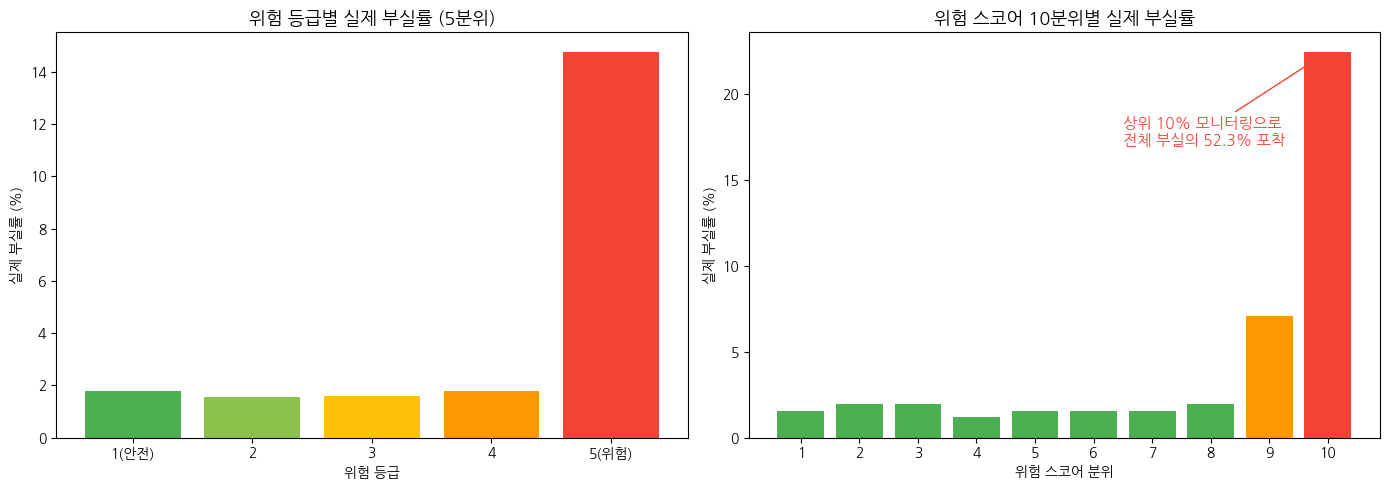

저장 완료: risk_score_validation.png


In [43]:
# 핵심지표 시각화

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트 설정
!apt-get -qq install fonts-nanum > /dev/null
fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 5분위(등급) 부실률
grade_summary_plot = score_df_valid.groupby('risk_grade', observed=True)['is_failed'].mean() * 100
axes[0].bar(grade_summary_plot.index.astype(str), grade_summary_plot.values, color=['#4CAF50','#8BC34A','#FFC107','#FF9800','#F44336'])
axes[0].set_title('위험 등급별 실제 부실률 (5분위)', fontsize=13)
axes[0].set_ylabel('실제 부실률 (%)')
axes[0].set_xlabel('위험 등급')

# 오른쪽: 10분위 부실률
decile_summary_plot = score_df_valid.groupby('risk_decile', observed=True)['is_failed'].mean() * 100
colors = ['#4CAF50']*8 + ['#FF9800', '#F44336']
axes[1].bar(decile_summary_plot.index.astype(str), decile_summary_plot.values, color=colors)
axes[1].set_title('위험 스코어 10분위별 실제 부실률', fontsize=13)
axes[1].set_ylabel('실제 부실률 (%)')
axes[1].set_xlabel('위험 스코어 분위')

# 핵심 메시지 주석 추가
axes[1].annotate('상위 10% 모니터링으로\n전체 부실의 52.3% 포착',
                  xy=(9, 22.44), xytext=(5.5, 17),
                  fontsize=11, fontweight='bold', color='#F44336',
                  arrowprops=dict(arrowstyle='->', color='#F44336'))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/risk_score_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print("저장 완료: risk_score_validation.png")

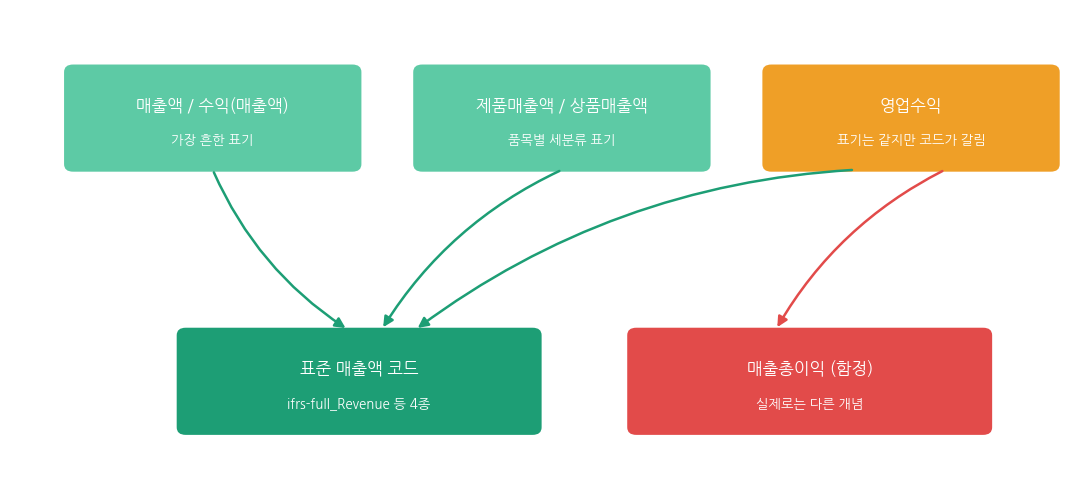

저장 완료: account_standardization_mapping.png


In [44]:
# 계정과목 표준화 문제를 보여주는 시각 자료

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 5))

def draw_box(x, y, w, h, title, subtitle, color, text_color='white'):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                          facecolor=color, edgecolor='none')
    ax.add_patch(box)
    ax.text(x + w/2, y + h*0.62, title, ha='center', va='center', fontsize=12, fontweight='bold', color=text_color)
    ax.text(x + w/2, y + h*0.28, subtitle, ha='center', va='center', fontsize=9.5, color=text_color)

def draw_arrow(x1, y1, x2, y2, color):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>', mutation_scale=15,
                             color=color, linewidth=1.8, connectionstyle="arc3,rad=0.15")
    ax.add_patch(arrow)

# 위쪽 박스 (원본 표기)
draw_box(0.5, 3.3, 2.6, 1.1, '매출액 / 수익(매출액)', '가장 흔한 표기', '#5DCAA5')
draw_box(3.6, 3.3, 2.6, 1.1, '제품매출액 / 상품매출액', '품목별 세분류 표기', '#5DCAA5')
draw_box(6.7, 3.3, 2.6, 1.1, '영업수익', '표기는 같지만 코드가 갈림', '#EF9F27')

# 아래쪽 박스 (표준 코드 / 함정)
draw_box(1.5, 0.5, 3.2, 1.1, '표준 매출액 코드', 'ifrs-full_Revenue 등 4종', '#1D9E75')
draw_box(5.5, 0.5, 3.2, 1.1, '매출총이익 (함정)', '실제로는 다른 개념', '#E24B4A')

# 화살표
draw_arrow(1.8, 3.3, 3.0, 1.6, '#1D9E75')
draw_arrow(4.9, 3.3, 3.3, 1.6, '#1D9E75')
draw_arrow(7.5, 3.3, 3.6, 1.6, '#1D9E75')
draw_arrow(8.3, 3.3, 6.8, 1.6, '#E24B4A')

ax.set_xlim(0, 9.5)
ax.set_ylim(0, 5)
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/account_standardization_mapping.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("저장 완료: account_standardization_mapping.png")

In [ ]:
# 5단계: AS-IS→TO-BE 프로세스 개선안, 조기경보 리포트 설계


## 1. AS-IS → TO-BE 프로세스 개선안
### AS-IS (현재 방식으로 가정)
#- 담당자가 개별 기업 재무제표를 수작업으로 열람하고 확인
#- 재무비율 계산이 담당자 개인 역량과 시간에 의존
#- 산업 특성을 감안하지 않은 절대 수치 위주 판단 (부채비율 200퍼센트가 위험한지 아닌지 업종마다 기준이 다른데 이를 반영하기 어려움)
#- 문제가 겉으로 드러난 뒤(연체, 부도 뉴스 등) 사후에 대응
#- 전체 상장사를 매번 다 들여다보기엔 인력 한계로 실제로는 일부만 주기적으로 검토

### TO-BE (제안하는 방식)
#- DART 재무제표를 자동 수집하고 표준화하는 파이프라인을 상시 운영
#- 산업 상대지표 기반 스코어링으로, 절대 수치가 아닌 업종 대비 이상 여부를 자동 판별
#- 전체 기업을 매 분기 일괄 스코어링하고 상위 10퍼센트 위험군을 자동으로 플래깅
#- 담당자는 전수 검토 대신 위험 상위 10퍼센트에 집중, 검토 리소스를 실질적 위험 기업에 배분
#- 사후 대응에서 사전 조기경보로 전환

### 프로세스 비교 요약
#| 구분 | AS-IS | TO-BE |
#|---|---|---|
#| 데이터 수집 | 수작업 열람 | API 기반 자동 수집 |
#| 판단 기준 | 절대 재무수치 | 업종 상대지표 |
#| 검토 범위 | 일부 기업, 비정기적 | 전체 기업, 정기 스코어링 |
#| 대응 시점 | 문제 발생 후 사후 대응 | 위험 신호 사전 포착 |
#| 리소스 배분 | 균등 분산 | 상위 위험군에 집중 |

## 2. 조기경보 리포트 설계

### 리포트 구성 요소
#1. 기업명, 산출 기준연도, 위험등급(5단계 중 몇 단계인지)
#2. 부실위험 스코어 (0에서 100점)
#3. 핵심 재무비율의 업종 대비 배율 (부채비율, 유동비율 등)
#4. 업종명
#5. 주요 경보 사유 (어떤 지표가 어느 정도 이상인지 구체적으로 명시)
#6. 검증 근거 (과거 유사 스코어 구간 기업의 실제 부실 전환율)

### 설계 원칙
#- 담당자가 재무제표 원본을 다시 열어보지 않아도 위험 판단이 가능하도록 핵심 지표를 요약
#- 스코어만 제시하지 않고 그 스코어를 신뢰할 수 있는 근거(과거 검증 결과)를 함께 제공
#- 업종 평균 대비 배율로 표시하여 절대 수치만으로는 파악하기 어려운 상대적 위험도를 직관적으로 전달

## 3. 활용 시나리오
#이번 프로젝트에서 설계한 스코어링 로직은 다음과 같은 방식으로 실제 서비스에 연결될 수 있습니다.

#- NICE BizLINE 등 기업정보 플랫폼의 조기경보 및 모니터링 기능에 스코어링 엔진으로 적용
#- B2B 여신심사 부서에 기업별 위험등급을 참고자료로 제공
#- 협력사, 거래처 리스크 관리팀에 정기 모니터링 리포트 형태로 제공

## 4. 검증된 효과
#실제 관리종목 지정 및 상장폐지 이력 184건을 대상으로 검증한 결과, 다음과 같은 성과를 확인했습니다.

#- 위험 스코어 상위 10퍼센트 기업의 실제 부실률은 22.44퍼센트로, 하위 80퍼센트 기업(1.2에서 2.0퍼센트 수준)보다 15배에서 19배 높음
#- 상위 10퍼센트 기업만 집중 모니터링해도 전체 부실 사례의 52.3퍼센트를 조기에 포착 가능